In [1]:
options(warn=-1)
library(tidyverse)
library(midasml)
library(imputeTS)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.1     v tibble    3.3.0
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.2.0     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [2]:
# helper function, generate lagged datasets for testing on vintages
gen_lagged_data <- function (metadata, data, last_date, lag) {
  # only go up to the last date
  lagged_data <- data %>% 
    dplyr::filter(date <= last_date)
  
  for (col in colnames(lagged_data)[2:length(colnames(lagged_data))]) {
    pub_lag <- metadata %>% 
      dplyr::filter(series == col) %>% 
      select(months_lag) %>% 
      pull()
    
    # go back as far as needed for the pub_lag of the variable, then + the lag (so -2 for 2 months back)
    condition <- (nrow(lagged_data) - pub_lag + lag)
    # only input NA if the lag is less than the latest row in the data
    if (condition <= nrow(lagged_data)) {
      lagged_data[condition:nrow(lagged_data), col] <- NA
    } 
  }
  lagged_data <- lagged_data %>% 
    dplyr::filter(!is.na(date))
  return (lagged_data)
}

# helper function, generate a dataset in the format required for the Midasml library
gen_midasml_dataset <- function (data, target_variable, degree, low_freq_lags, high_freq_lags, train_start_date, train_end_date) {
    # fill data with means
    for (covariate in colnames(data)) {
      if (covariate != target_variable) {
        data[,covariate] <- na_mean(data[,covariate])
      }
    }
    
    # weights
    w <- lb(degree = degree, jmax = high_freq_lags) 
    
    mfd <- list()
    for (covariate in colnames(data)) {
      if (!(covariate %in% c(target_variable, "date"))) {
        mfd[[covariate]] <- mixed_freq_data(
          data[,target_variable], 
          as.Date(data[,"date"]),
          data[,covariate], 
          data[,"date"],
          x.lag = high_freq_lags, 
          y.lag = low_freq_lags, 
          horizon = 1,
          train_start_date, 
          train_end_date, 
          disp.flag = F
        )
      }
    }
    
    y <- mfd[[1]]$est.y
    x <- mfd[[1]]$est.lag.y #, mfd$est.x%*%w, mfd2$est.x%*%w)
    for (covariate in colnames(data)) {
      if (!(covariate %in% c(target_variable, "date"))) {
        x <- cbind(x, mfd[[covariate]]$est.x%*%w)
      }
    }
    
    gindex <- c()
    for (i in 1:(ncol(data)-1)) {
      gindex <- c(gindex, rep(i, dim(mfd[[1]]$est.lag.y)[2])) 
    }
    return (list("y"=y, "x"=x, "gindex"=gindex))
}

# Data set up

In [3]:
# full data read
metadata <- read_csv("../data/meta_data.csv")
data <- read_csv("../data/data_tf.csv") %>%
  arrange(date)

target_variable <- "gdpc1"

# which lags to assess
lags <- -2:2

# dates for training and test
# test set is shorter in this example notebook than in the paper to save runtime. Set test_start_date to "2002-03-01" and test_end_date to "2022-09-01" for results of the paper.
train_start_date <- "1947-01-01"
test_start_date <- "2005-03-01"
test_end_date <- "2010-03-01"

# will have a rolling test period, so model for e.g. 2002-03-01 is trained with data as it would have appeared on 2003-01-01, 2002-06-01 as it would have appeared on 2002-04-01, and so on. 
# This mimics the real-world nowcasting scenario
test_dates <- seq(as.Date(test_start_date), as.Date(test_end_date), by = "3 months")
train_end_dates <- lapply(test_dates, function (x) seq(x, by="-2 months", length=2)[2]) %>% 
    unlist() %>% 
    as.Date(origin = "1970-01-01")

# test dataset
test <- data %>%
    dplyr::filter(date >= train_start_date, date <= test_end_date) %>%
    # the nowcastDFM library only works with dataframe, may get errors in estimation if you use tibbles
    data.frame()

# replace any infinites with NA
for (col in colnames(test)) {
    if (sum(is.infinite(test[,col])) > 0) {
      test[is.infinite(test[,col]), col] <- NA 
    }
}

Rows: 24 Columns: 8
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (3): series, name, freq
dbl (5): block_g, block_s, block_r, block_l, months_lag

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 913 Columns: 25
-- Column specification --------------------------------------------------------
Delimiter: ","
dbl  (24): payems, gdpc1, cpiaucsl, dgorder, hsn1f, rsafs, unrate, houst, in...
date  (1): date

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


Data should be a dataframe of seasonally adjusted growth rates with months in rows and quarterly variables in the last month of the quarter, with `np.nan`s for interquarter months.

In [4]:
tail(data)

date,payems,gdpc1,cpiaucsl,dgorder,hsn1f,rsafs,unrate,houst,indpro,...,ir,cpilfesl,pcepilfe,pcepi,permit,tcu,businv,ulcnfb,iq,a261rx1q020sbea
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2022-08-01,0.001915508,NA,0.0011819650,0.002335260,0.18968692,0.006719933,0.05714286,0.09513435,-0.0006862216,...,-0.012295082,0.005672678,0.005504572,0.002682399,-0.08486647,-0.002056898,0.009037228,NA,-0.013707165,NA
2022-09-01,0.001761255,0.008011552,0.0038596847,0.002037679,-0.13467492,-0.001672780,-0.05405405,-0.02851459,0.0038251759,...,-0.010373444,0.005758545,0.004644000,0.003443036,0.01426719,0.002560770,0.002484690,0.005911377,-0.009475679,0.002056349
2022-10-01,0.001856197,NA,0.0043839992,0.007361543,0.08228980,0.013065747,0.05714286,-0.02116041,-0.0006249231,...,-0.004192872,0.002715462,0.002616225,0.003729239,-0.03324808,-0.001788585,0.002912884,NA,-0.003826531,NA
2022-11-01,0.001715758,NA,0.0009628869,-0.020892196,0.05785124,-0.005824232,0.00000000,-0.00488145,-0.0021948039,...,-0.006315789,0.001986837,0.001680901,0.001043196,-0.10648148,-0.003270767,NA,NA,-0.002560819,NA
2022-12-01,NA,NA,NA,NA,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2023-01-01,NA,NA,NA,NA,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


# Training the model

The model is trained on a rolling basis. So if we are predicting 2000-03-01, the model is trained on data as it would have appeared in 1999-12-01, right before the beginning of the prediction period.

# Testing the model on artificial data vintages

In [5]:
# dataframe for predictions
pred_dict <- data.frame(date = test_dates)
for (lag in lags) {
  pred_dict[,as.character(lag)] <- NA
}

# model hyperparameters
gamma <- 0.25
degree <- 3
low_freq_lags <- 4
high_freq_lags <- 9

In [6]:
# looping through test dates
for (i in 1:length(test_dates)) {
    # training the actual model
    train <- test %>%
        dplyr::filter(date <= seq(as.Date(test_dates[i]), by="-3 months", length=2)[2]) # data as it would have appeared at beginning of prediction period
    
    dataset <- gen_midasml_dataset(train, target_variable, degree, low_freq_lags, high_freq_lags, train_start_date, test_dates[i])
    
    # estimating Midasml model
    model <- cv.sglfit(dataset$x, dataset$y, gamma = gamma, gindex = dataset$gindex, nfold = 10)
   
    # testing the model on artificial vintages  
    for (lag in lags) {
        lagged_data <- gen_lagged_data(metadata, test, test_dates[i], lag) %>% 
          data.frame
        # make sure actual value not in there
        lagged_data[lagged_data$date == test_dates[i], target_variable] <- NA
        
        # need to have a value in target gdp period to have model estimate
        for (j in c(0, 3, 6, 9)) {
            if(is.na(lagged_data[nrow(lagged_data)-j, target_variable])) {
                  lagged_data[nrow(lagged_data)-j, target_variable] <- mean(lagged_data[,target_variable], na.rm=TRUE)
            }
        }
        lagged_dataset <- gen_midasml_dataset(lagged_data, target_variable, degree, low_freq_lags, high_freq_lags, train_start_date, test_dates[i])

        # getting prediction
      preds <- predict(model, newx = lagged_dataset$x, s = 'lam.min')
      
      # appending to prediction dictionary
      pred_dict[pred_dict$date == test_dates[i], as.character(lag)] <- preds[nrow(preds)] # last row of matrix is prediction period
    }
}

# Assess and visualize model performance

In [7]:
actuals <- test %>%
    filter(date >= test_start_date) %>%
    filter(substr(date, 6, 7) %in% c("03", "06", "09", "12")) %>%
    select(!!target_variable) %>%
    pull()

In [8]:
performance <- data.frame(Vintage = numeric(), RMSE = numeric())
for (lag in lags) {
    tmp = data.frame(
        Vintage = lag,
        RMSE = sqrt(mean((actuals - pred_dict[,as.character(lag)])**2))
    )
    performance = rbind(performance, tmp)
}
round(performance, 4)

Vintage,RMSE
<dbl>,<dbl>
-2,0.0053
-1,0.0051
0,0.0061
1,0.0059
2,0.0059


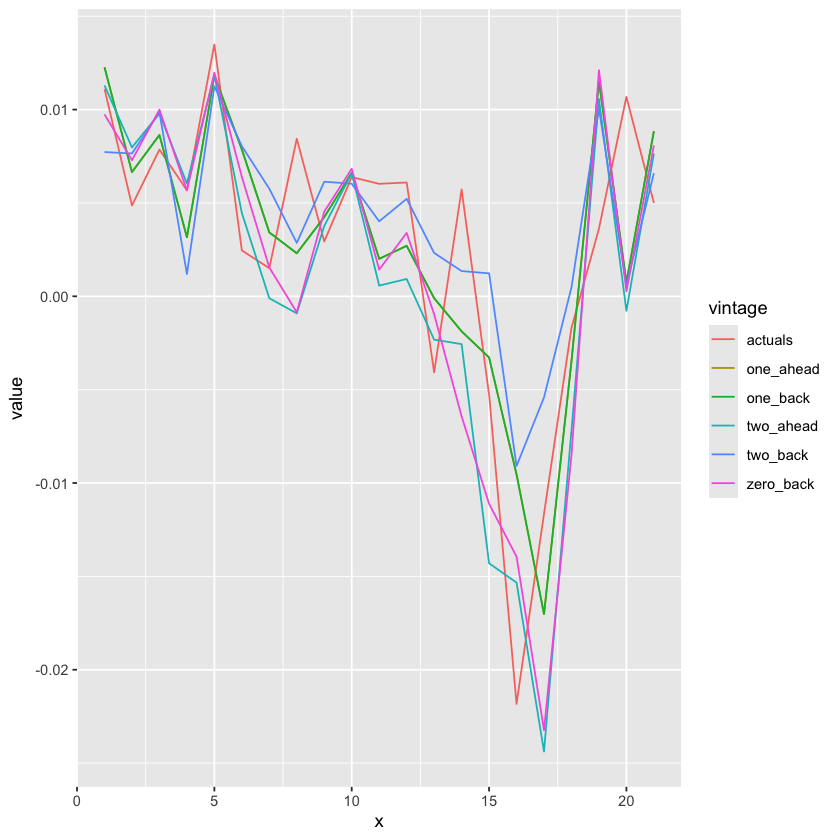

In [9]:
# plot of predictions vs actuals
p <- tibble(
    actuals = actuals,
    two_back = pred_dict[, "-2"], 
    one_back = pred_dict[, "-1"], 
    zero_back = pred_dict[, "0"],
    one_ahead = pred_dict[, "-1"],
    two_ahead = pred_dict[, "2"]
) %>%
    mutate(x = 1:n()) %>%
    gather(vintage, value, -x) %>%
    ggplot() + 
    aes(x=x, y=value, color=vintage) + 
    geom_line()
p

# Final model usage / getting predictions on new data
Say model selection is finished and the model is to now be used, i.e. used to get predictions on new data.

In [10]:
# the test data ends 2010-03-01, let's say we wanted to predict 2010-06-01
new_data <- test

# the date we want predicted must be in the date, if it's not there it must be added
desired_date <- "2010-06-01"
months_to_add <- seq(max(new_data$date), as.Date(desired_date), by="month") %>% as.character()

for (value in months_to_add[2:length(months_to_add)]) {
    new_data[nrow(new_data) + 1, "date"] <- value
}

# we can now confirm the date we want to forecast is in the dataframe, even if all values are missing
new_data %>% tail()

# make it into a Midasml dataset
new_dataset <- gen_midasml_dataset(new_data, target_variable, degree, low_freq_lags, high_freq_lags, train_start_date, new_data$date[nrow(new_data)])

,date,payems,gdpc1,cpiaucsl,dgorder,hsn1f,rsafs,unrate,houst,indpro,...,ir,cpilfesl,pcepilfe,pcepi,permit,tcu,businv,ulcnfb,iq,a261rx1q020sbea
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
757,2010-01-01,1.540975e-05,NA,0.0006487322,0.127685024,-0.01988636,-8.379759e-05,-0.01010101,0.05679862,0.010900832,...,0.0120578778,-0.0011227765,0.0014678326,2.186252e-03,-0.04216867,0.012824908,0.001697060,NA,0.008354219,NA
758,2010-02-01,-7.088374e-04,NA,-0.0009517766,-0.003126795,-0.02608696,2.288733e-03,0.00000000,-0.01628664,0.003535007,...,-0.0007942812,0.0004441765,0.0008731718,-3.146369e-05,0.02201258,0.005553038,0.006594576,NA,-0.003314002,NA
759,2010-03-01,1.395550e-03,0.005000535,0.0003313681,0.009409809,0.13392857,2.169620e-02,0.01020408,0.05298013,0.007105439,...,0.0039745628,0.0002355809,0.0014955601,1.415911e-03,0.05692308,0.009229304,0.004449005,-0.01190992,0.007481297,0.005756856
760,2010-04-01,NA,NA,NA,NA,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
761,2010-05-01,NA,NA,NA,NA,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
762,2010-06-01,NA,NA,NA,NA,NA,NA,NA,NA,NA,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [11]:
# training the actual model
model <- cv.sglfit(new_dataset$x, new_dataset$y, gamma = gamma, gindex = new_dataset$gindex, nfold = 10)

In [12]:
# getting prediction
preds <- predict(model, newx = new_dataset$x, s = 'lam.min')
preds[nrow(preds)] # prediction for target period 2010-06-01 corresponds to last row of preds

[1] 0.007014659